In [32]:
from luminis_mc import load_sweep_data
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
})

In [50]:
def plot_absortion_image(absortion, abs_r_len, abs_z_len, title="Absoriton"):
    fig = plt.figure(figsize=(8, 6))
    fig.suptitle(f"{title}", fontsize=16)
    extent = [0.0, abs_z_len, -abs_r_len, abs_r_len]
    plt.imshow(absortion, cmap='inferno', origin='lower', extent=extent, aspect='auto')
    plt.xlabel("Depth $[l]$")
    plt.ylabel("Radius $[l]$")
    plt.colorbar(label="Absorption (a.u.)")
    plt.tight_layout()
    plt.show()
    
def plot_absortion_image_timed(absorption_datas, indexes, abs_r_len, abs_z_len, title="Absoriton"):
    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(f"{title}", fontsize=16)

    n_cols = 2
    n_rows = (len(indexes) + n_cols - 1) // n_cols

    for i, idx in enumerate(indexes):
        absorption_data = absorption_datas.absorption_image("absorption", idx)

        ax = fig.add_subplot(n_rows, n_cols, i + 1)
        extent = [0.0, abs_z_len, -abs_r_len, abs_r_len]
        ax.imshow(absorption_data, cmap='inferno', origin='lower', extent=extent, aspect='auto')
        # ax.imshow(absorption_data, cmap='inferno', origin='lower', extent=extent, aspect='auto', norm=plt.matplotlib.colors.LogNorm())
        ax.set_title(f"t={idx * 1.0:.1f} ns")
        ax.set_xlabel("Depth $[l]$")
        ax.set_ylabel("Radius $[l]$")

    plt.tight_layout()
    plt.show()

In [51]:
base_dir = "/Users/niaggar/Documents/Thesis/Progress/09Mar26/"
dir_name = "absortion_layered"
path_sweep = base_dir + dir_name
sweep_data = load_sweep_data(path_sweep)

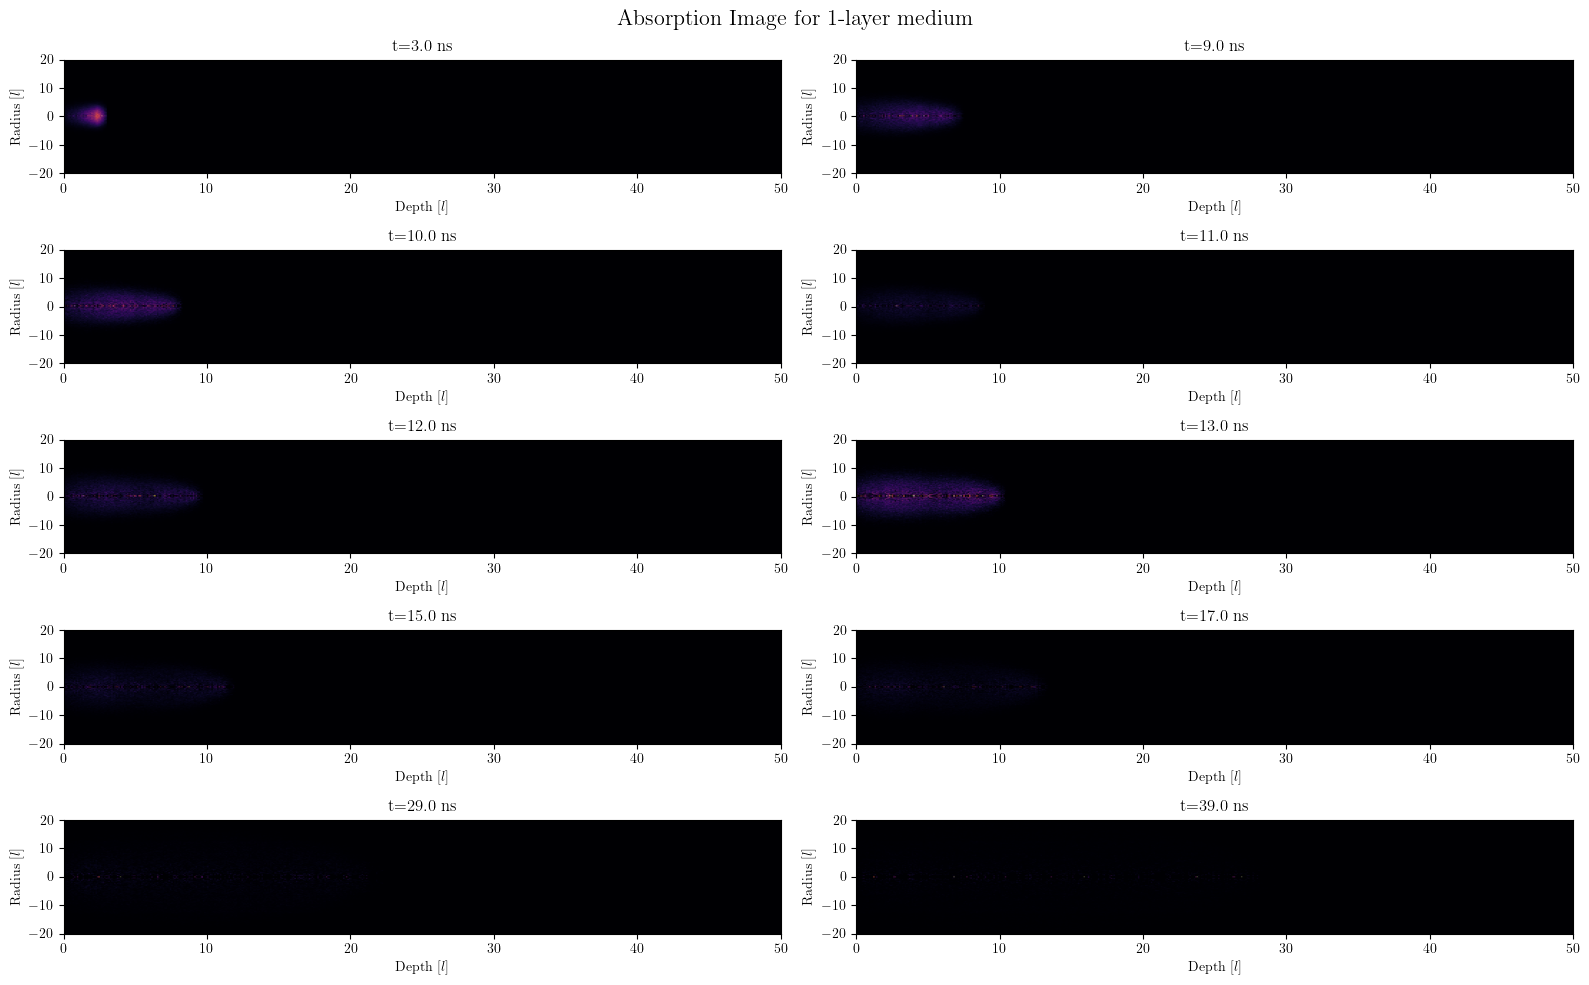

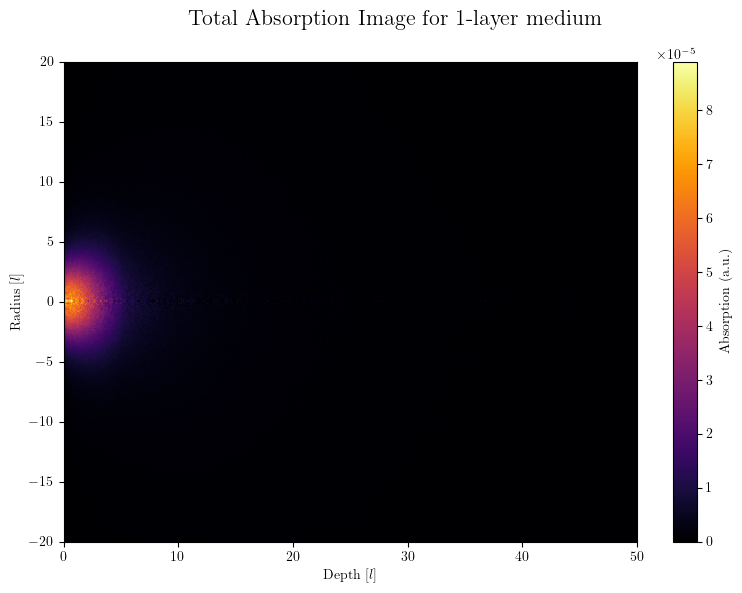

In [53]:
test = sweep_data['0001_layers_5']
test.absorption_image("absorption", 0)
meta_absorption = test.absorption_meta("absorption")

indexes = [3, 9, 10, 11, 12, 13, 15, 17, 29, 39]
plot_absortion_image_timed(test, indexes, meta_absorption['radius'], meta_absorption['depth'], title="Absorption Image for 1-layer medium")
plot_absortion_image(test.absorption_total_image("absorption"), meta_absorption['radius'], meta_absorption['depth'], title="Total Absorption Image for 1-layer medium")